Import libraries

In [13]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

Data Preprocessing

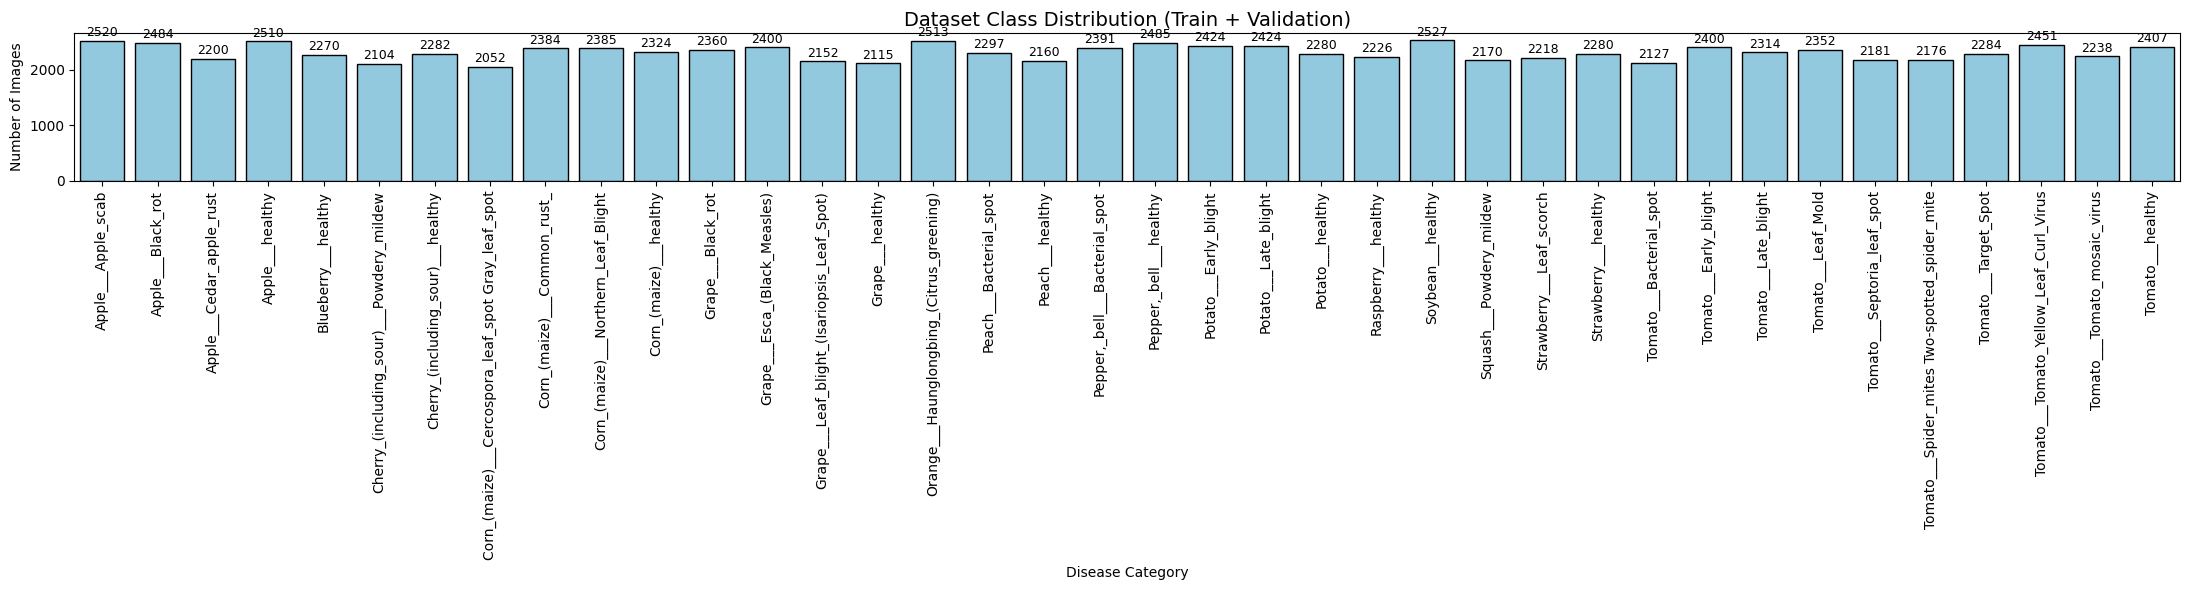

In [ ]:
DATASET_DIR = r"D:\Shalviii\2 month project\Plant disease detection" 
import os
import matplotlib.pyplot as plt
import seaborn as sns
train_path = os.path.join(DATASET_DIR, "train")
valid_path = os.path.join(DATASET_DIR, "valid")
def count_images(folder_path):
    class_counts = {}
    for cls in os.listdir(folder_path):
        cls_path = os.path.join(folder_path, cls)
        if os.path.isdir(cls_path):
            class_counts[cls] = len(os.listdir(cls_path))
    return class_counts

train_counts = count_images(train_path)
valid_counts = count_images(valid_path)
total_counts = {}
for cls in set(train_counts.keys()).union(valid_counts.keys()):
    total_counts[cls] = train_counts.get(cls, 0) + valid_counts.get(cls, 0)
sorted_counts = dict(sorted(total_counts.items(), key=lambda x: x[0]))
plt.figure(figsize=(22,6))
sns.barplot(x=list(sorted_counts.keys()), y=list(sorted_counts.values()), color="skyblue", edgecolor="black")
for idx, val in enumerate(sorted_counts.values()):
    plt.text(idx, val + 30, str(val), ha='center', va='bottom', fontsize=9)

plt.xticks(rotation=90)
plt.title("Dataset Class Distribution (Train + Validation)", fontsize=14)
plt.xlabel("Disease Category")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()


Training Image Preprocessing

In [14]:
training_set=tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 70295 files belonging to 38 classes.


Validation Image Preprocessing

In [15]:
validation_set=tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


In [16]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [17]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[182.   169.   176.  ]
   [174.75 161.75 168.75]
   [178.25 165.25 172.25]
   ...
   [152.   133.   139.  ]
   [163.25 144.25 150.25]
   [153.   134.   140.  ]]

  [[174.5  161.5  168.5 ]
   [167.75 154.75 161.75]
   [175.25 162.25 169.25]
   ...
   [158.5  139.5  145.5 ]
   [161.   142.   148.  ]
   [156.   137.   143.  ]]

  [[164.25 151.25 158.25]
   [171.75 158.75 165.75]
   [183.75 170.75 177.75]
   ...
   [166.   147.   153.  ]
   [164.5  145.5  151.5 ]
   [151.   132.   138.  ]]

  ...

  [[179.5  166.5  175.5 ]
   [167.5  154.5  163.5 ]
   [156.25 143.25 152.25]
   ...
   [128.5  108.5  117.5 ]
   [144.25 124.25 133.25]
   [132.5  112.5  121.5 ]]

  [[159.5  146.5  155.5 ]
   [176.5  163.5  172.5 ]
   [173.5  160.5  169.5 ]
   ...
   [127.25 107.25 116.25]
   [127.25 107.25 116.25]
   [133.   113.   122.  ]]

  [[166.75 153.75 162.75]
   [150.75 137.75 146.75]
   [152.   139.   148.  ]
   ...
   [136.75 116.75 125.75]
   [134.5  114.5  123.5 ]
   [133.   113.   12

Building Model

In [21]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [22]:
model=Sequential()

To avoid overshooting Loss function


1.Choose small learning rate default 0.001 here we have taken 0.0001
2.There may be chance of underfitting so increase number of neuron
3.Add more Convolutional Layer to extract more feature from images there may be possibilty that model unable to capture relevant feature or model is confusing due to lack of feature so feed with more feature

Building convolution layer

In [23]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

C:\Users\Lenovo\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [26]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [27]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [28]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [29]:
model.add(Dropout(0.25)) #To avoid overfitting

In [30]:
model.add(Flatten())

In [31]:
model.add(Dense(units=1500,activation='relu'))

In [32]:
model.add(Dropout(0.4))

In [33]:
#Output Layer
model.add(Dense(units=38,activation='softmax'))

Compiling Model

In [34]:
model.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [ ]:
model.summary() 

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)                    │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 128, 128, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 62, 62, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 31, 31, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 31, 31, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 29, 29, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 14, 14, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 12, 12, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 6, 6, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1500)                │       3,073,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1500)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 38)                  │          57,038 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

Model Training

In [36]:
training_history=model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3920s 2s/step - accuracy: 0.4020 - loss: 2.1108 - val_accuracy: 0.8362 - val_loss: 0.5295
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 5881s 3s/step - accuracy: 0.8318 - loss: 0.5388 - val_accuracy: 0.8923 - val_loss: 0.3452
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3748s 2s/step - accuracy: 0.9010 - loss: 0.3110 - val_accuracy: 0.9187 - val_loss: 0.2560
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 4089s 2s/step - accuracy: 0.9298 - loss: 0.2124 - val_accuracy: 0.9124 - val_loss: 0.2792
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 4139s 2s/step - accuracy: 0.9478 - loss: 0.1601 - val_accuracy: 0.9405 - val_loss: 0.1905
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3752s 2s/step - accuracy: 0.9608 - loss: 0.1208 - val_accuracy: 0.9515 - val_loss: 0.1620
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 4212s 2s/step - accuracy: 0.9667 - loss: 0.0999 - val_accuracy: 0.9595 - val_loss: 0.1271
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3418s 2s/step - accuracy: 0.9750 -

Model Evaluation

In [38]:
train_loss,train_acc=model.evaluate(training_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 3278s 1s/step - accuracy: 0.9764 - loss: 0.0676


In [39]:
print(train_loss,train_acc)

0.06169246509671211 0.9787893891334534


Model on validation set

In [40]:
val_loss,val_acc=model.evaluate(validation_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 295s 532ms/step - accuracy: 0.9451 - loss: 0.1919


In [41]:
print(val_loss,val_acc)

0.18418405950069427 0.9461074471473694


saving model

In [44]:
model.save("trained_model.keras")

In [45]:
training_history.history

{'accuracy': [0.5985347628593445,
  0.8559641242027283,
  0.9118002653121948,
  0.9374777674674988,
  0.9536809325218201,
  0.9635109305381775,
  0.968376100063324,
  0.9754890203475952,
  0.9791165590286255,
  0.9805391430854797],
 'loss': [1.3578475713729858,
  0.4540453553199768,
  0.275107741355896,
  0.19140277802944183,
  0.14150972664356232,
  0.11152440309524536,
  0.09493322670459747,
  0.07506071776151657,
  0.06440984457731247,
  0.05828156694769859],
 'val_accuracy': [0.8361598253250122,
  0.892328679561615,
  0.9187343716621399,
  0.912417471408844,
  0.9404734969139099,
  0.9514568448066711,
  0.9594810009002686,
  0.9470748901367188,
  0.957659900188446,
  0.9461074471473694],
 'val_loss': [0.5294668078422546,
  0.3451772630214691,
  0.2560192048549652,
  0.2791614234447479,
  0.19052061438560486,
  0.16199307143688202,
  0.1271262913942337,
  0.17998546361923218,
  0.13595445454120636,
  0.18418413400650024]}

In [46]:
#Recording history in json
import json
with open("training_hist.json","w") as f:
    json.dump(training_history.history,f)

In [47]:
training_history.history['accuracy']

[0.5985347628593445,
 0.8559641242027283,
 0.9118002653121948,
 0.9374777674674988,
 0.9536809325218201,
 0.9635109305381775,
 0.968376100063324,
 0.9754890203475952,
 0.9791165590286255,
 0.9805391430854797]

Accurary visualzation

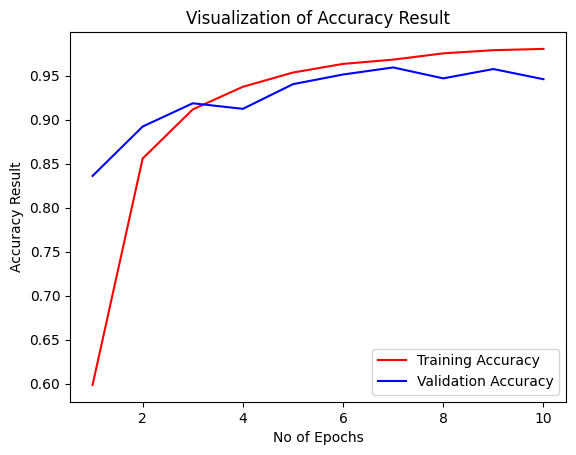

In [50]:
epochs=[i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel("No of Epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()

Some other metrics for model evaluation

In [51]:
class_name=validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [52]:
test_set=tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


In [53]:
y_pred=model.predict(test_set)
y_pred,y_pred.shape

550/550 ━━━━━━━━━━━━━━━━━━━━ 267s 472ms/step


(array([[9.9897337e-01, 1.0064535e-03, 1.3872814e-07, ..., 2.6758138e-12,
         1.0316219e-12, 2.5449419e-11],
        [9.9942744e-01, 4.5778637e-04, 2.4861119e-08, ..., 2.8556090e-12,
         6.0907019e-13, 2.9923095e-12],
        [9.9978453e-01, 1.6029358e-06, 1.2048894e-08, ..., 6.7412391e-14,
         3.5529021e-12, 2.3633113e-11],
        ...,
        [9.9647435e-10, 1.7941671e-11, 2.5062223e-08, ..., 3.7864559e-10,
         3.0966346e-10, 9.9999177e-01],
        [2.4974078e-09, 5.8625249e-12, 5.7300715e-09, ..., 7.7505096e-09,
         1.4983516e-10, 9.9999738e-01],
        [7.7124057e-14, 1.5544166e-13, 1.3832362e-13, ..., 1.5915942e-13,
         6.3890332e-13, 9.9999809e-01]], dtype=float32),
 (17572, 38))

In [54]:
predicted_categories=tf.argmax(y_pred,axis=1)

In [55]:
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [56]:
true_categories=tf.concat([y for x,y in test_set],axis=0)
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [57]:
Y_true=tf.argmax(true_categories,axis=1)
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [62]:
from sklearn.metrics import classification_report,confusion_matrix

In [59]:
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.97      0.93      0.95       504
                                 Apple___Black_rot       0.89      0.98      0.93       497
                          Apple___Cedar_apple_rust       0.93      0.99      0.96       440
                                   Apple___healthy       0.97      0.93      0.95       502
                               Blueberry___healthy       0.93      0.99      0.96       454
          Cherry_(including_sour)___Powdery_mildew       1.00      0.93      0.96       421
                 Cherry_(including_sour)___healthy       0.95      1.00      0.97       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.98      0.87      0.92       410
                       Corn_(maize)___Common_rust_       1.00      0.99      1.00       477
               Corn_(maize)___Northern_Leaf_Blight       0.90      0.99      0.

In [65]:
cm=confusion_matrix(Y_true,predicted_categories)
cm

array([[471,   9,   0, ...,   0,   0,   0],
       [  0, 489,   0, ...,   0,   0,   0],
       [  0,   0, 434, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ..., 477,   0,   0],
       [  0,   0,   0, ...,   0, 443,   0],
       [  0,   0,   1, ...,   0,   0, 474]], dtype=int64)

Confusion Matrix Visualization

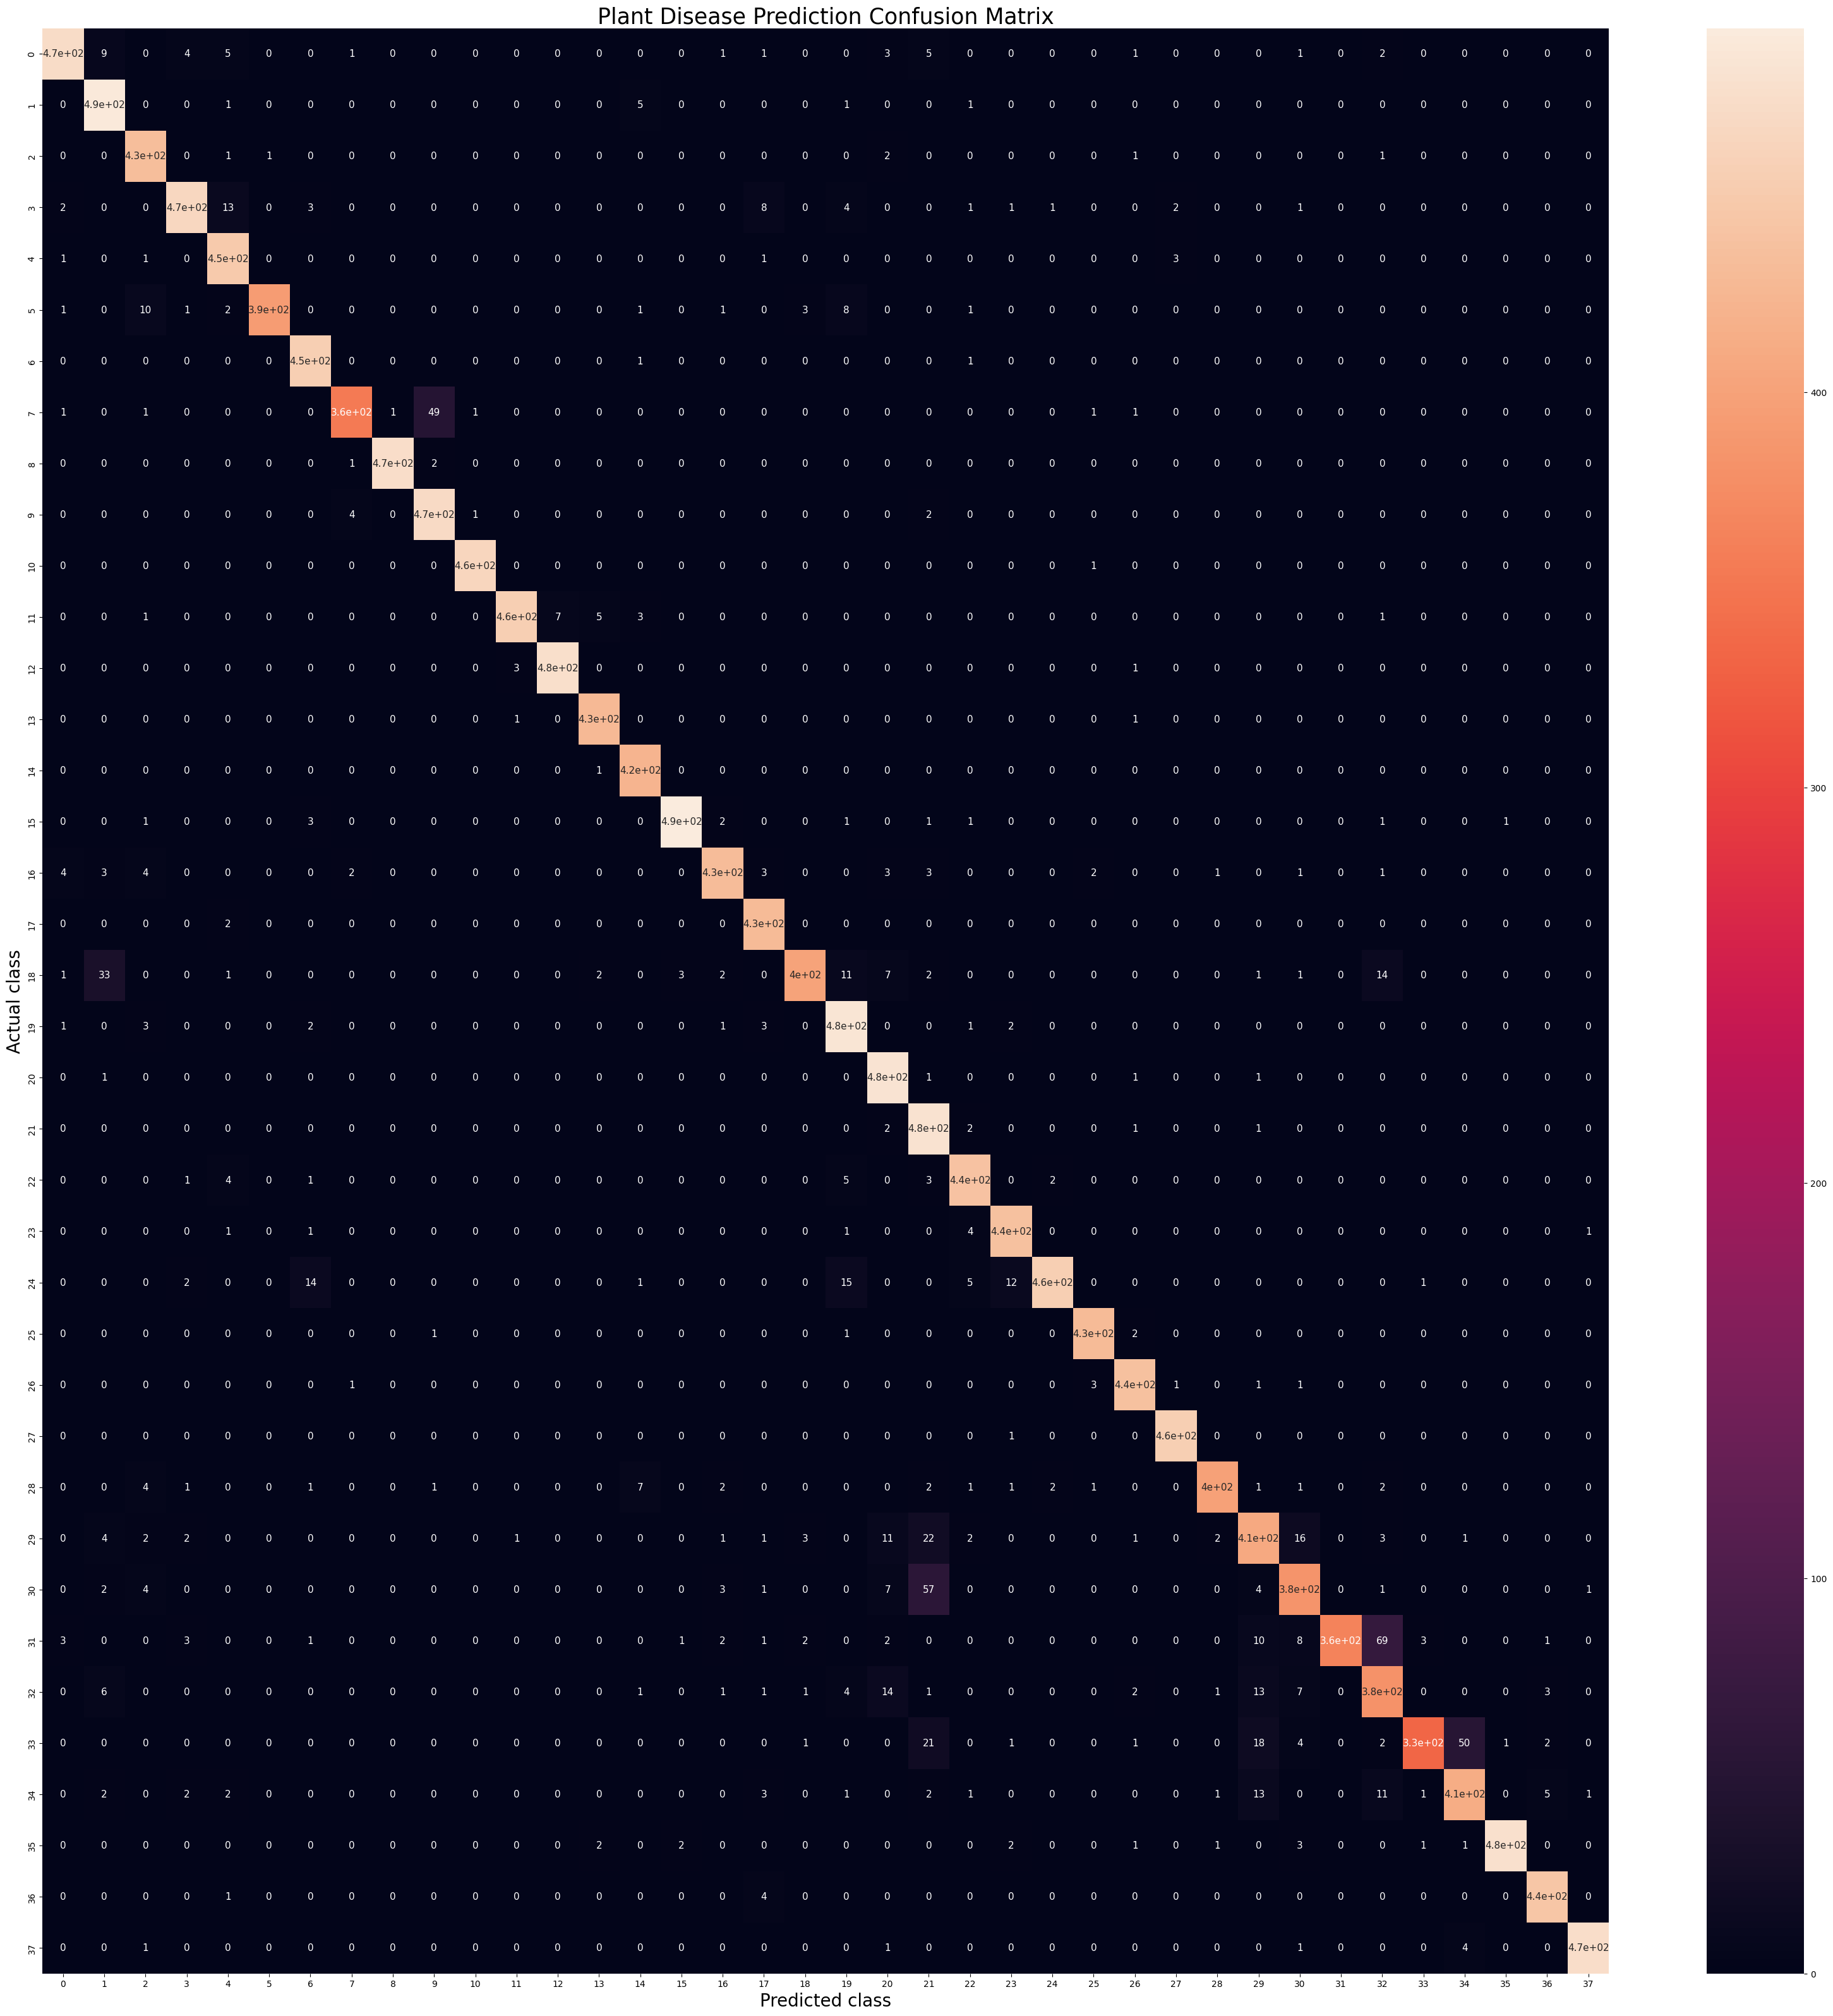

In [75]:
plt.figure(figsize=(40,40))
sns.heatmap(cm,annot=True,annot_kws={'size':11})
plt.xlabel("Predicted class",fontsize=20)
plt.ylabel("Actual class",fontsize=20)
plt.title("Plant Disease Prediction Confusion Matrix",fontsize=25)
plt.show()

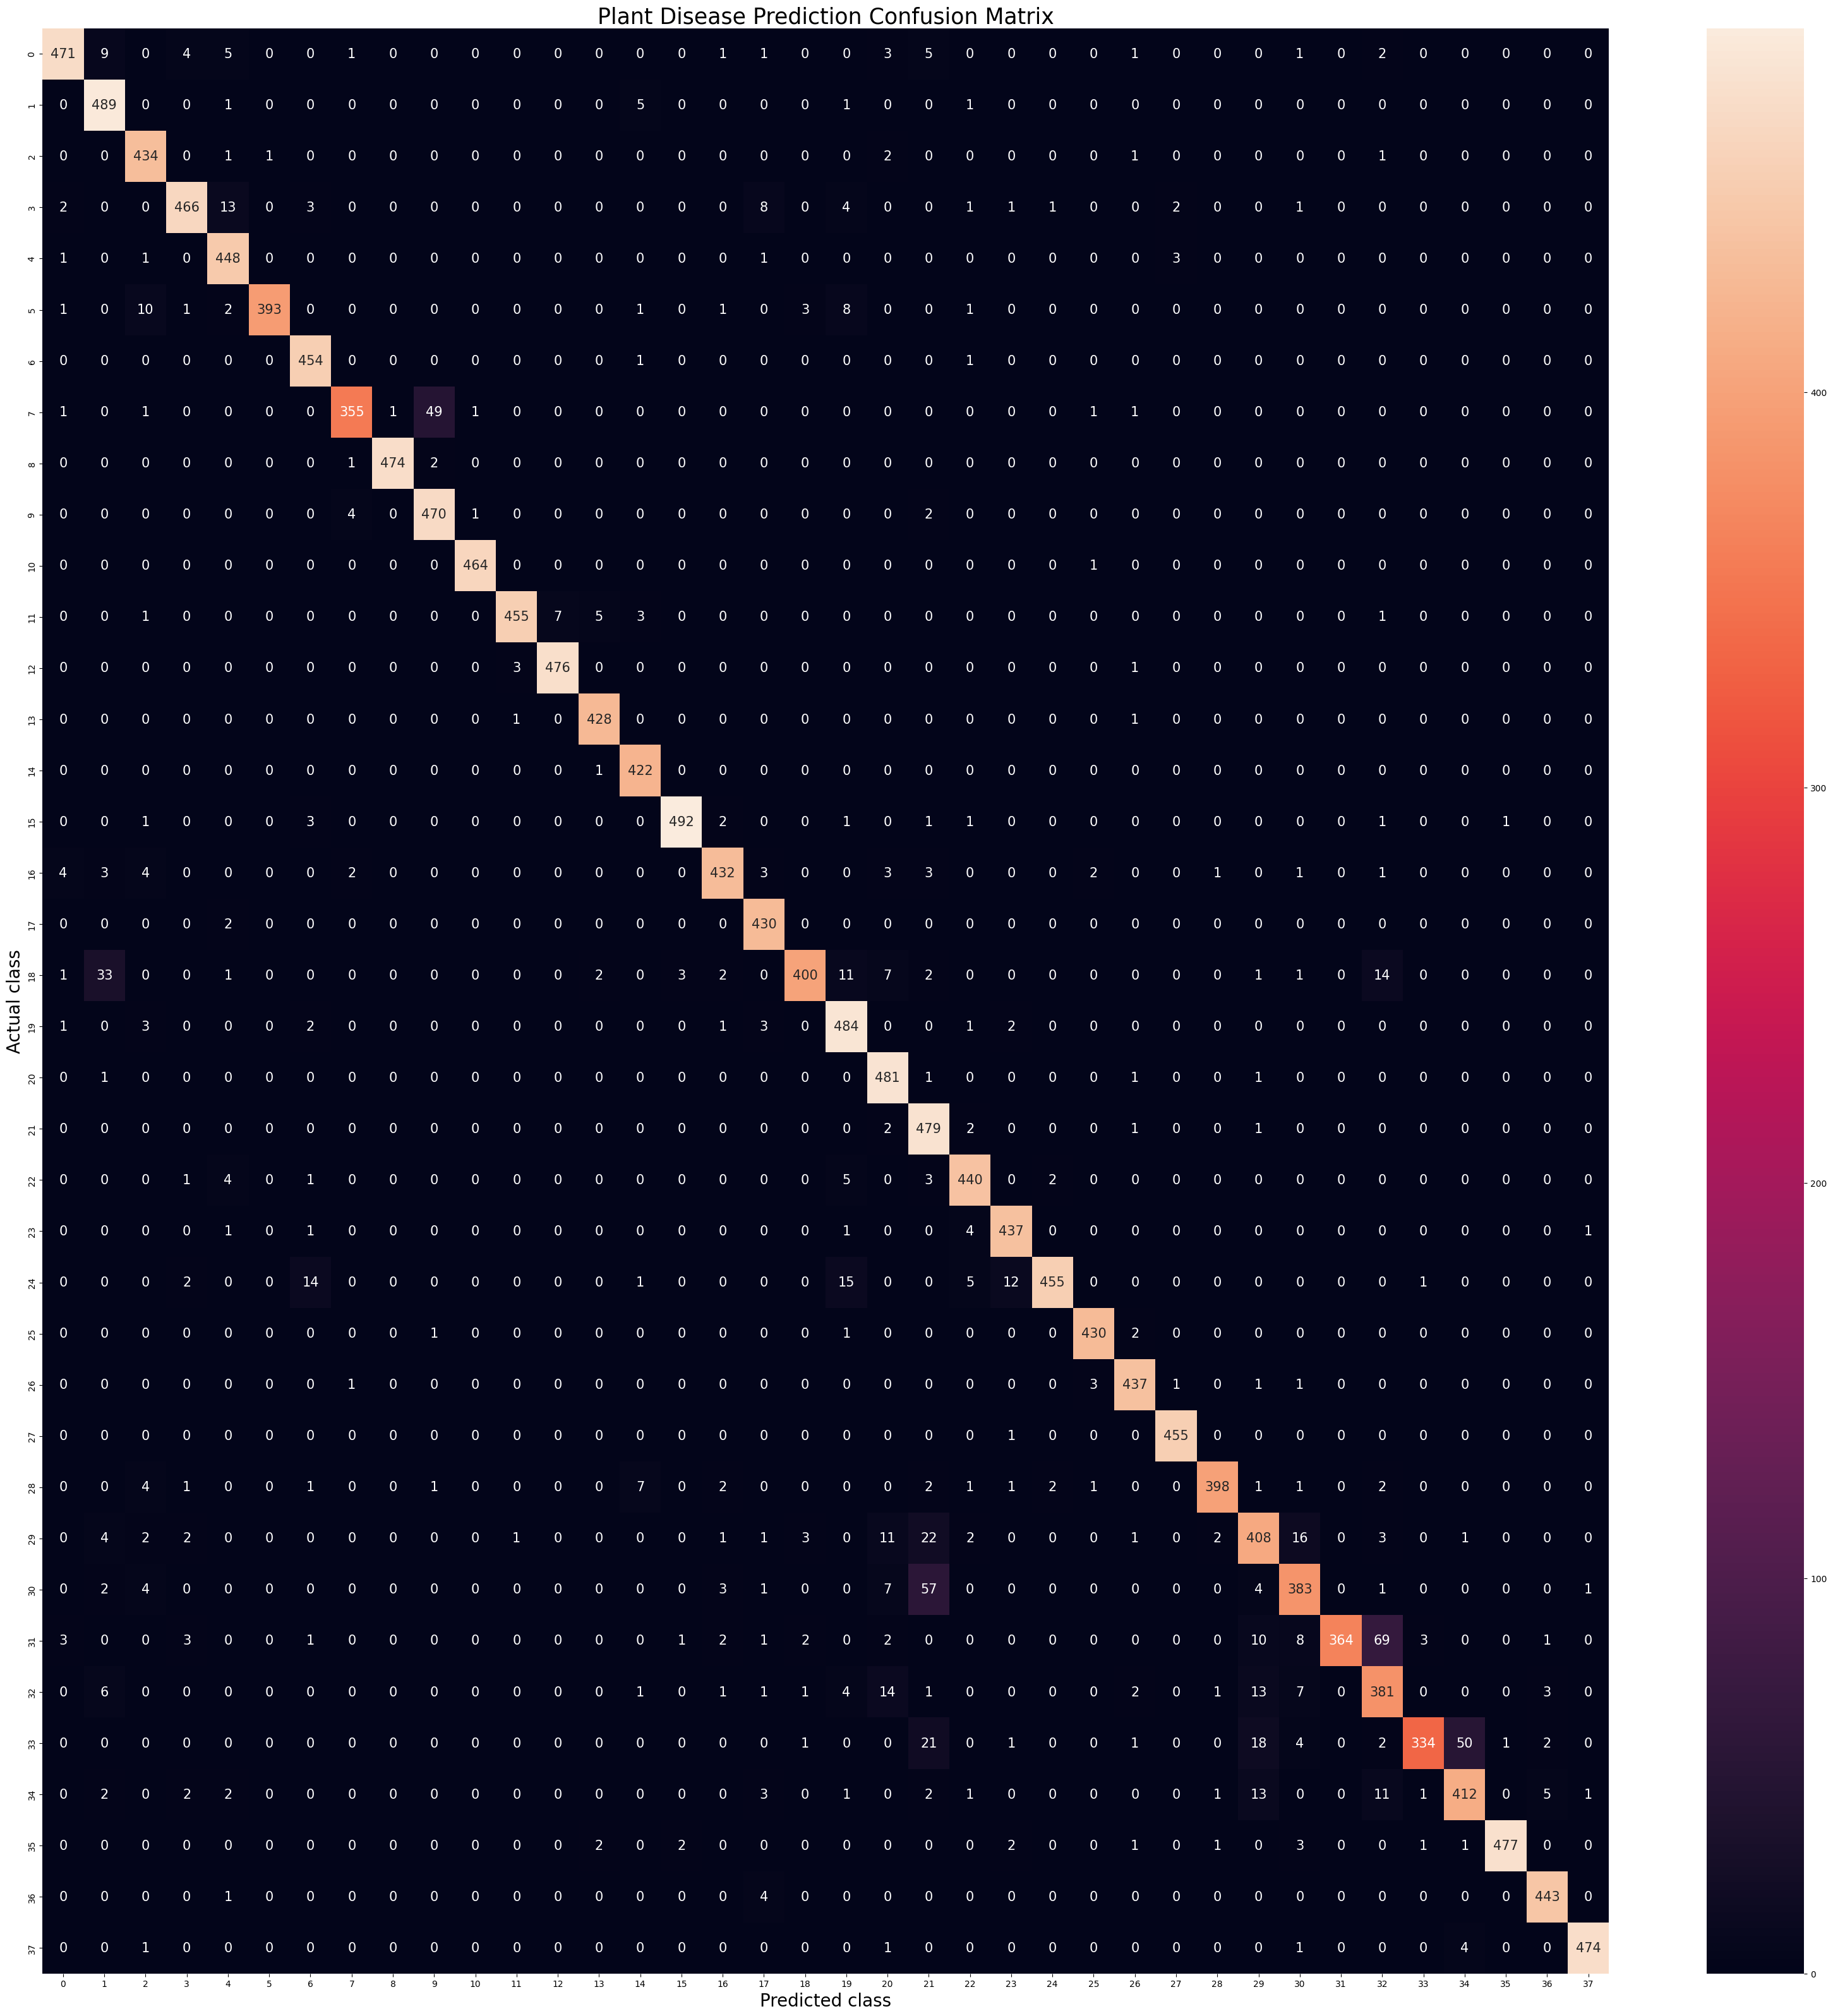

In [78]:
plt.figure(figsize=(40,40))
sns.heatmap(cm, annot=True, fmt='g', annot_kws={'size':15})  # fmt='g' disables scientific notation
plt.xlabel("Predicted class", fontsize=20)
plt.ylabel("Actual class", fontsize=20)
plt.title("Plant Disease Prediction Confusion Matrix", fontsize=25)
plt.show()

In [ ]:
To address imbalanced classes, thisutilizes the compute_class_weight function from sklearn.utils.